# CNN Lab Assignment
**Name:** Zoya Altaf  
**Roll Number:** 24CD3052 
**Framework:** TensorFlow/Keras

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("All packages working! ✓")


TensorFlow: 2.21.0
NumPy: 2.2.5
All packages working! ✓


In [2]:
# Setting random seeds for reproducibility
# np.random.seed controls NumPy random operations
# tf.random.set_seed controls TensorFlow random operations
import random
import numpy as np
import tensorflow as tf

random.seed(42)        # controls Python random module
np.random.seed(42)     # controls NumPy random operations
tf.random.set_seed(42) # controls TensorFlow random operations

# Verify package versions
import matplotlib
import pandas as pd
import sklearn
import seaborn

print("Package Versions:")
print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Matplotlib :", matplotlib.__version__)
print("Pandas     :", pd.__version__)
print("Sklearn    :", sklearn.__version__)
print("Seaborn    :", seaborn.__version__)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("\nGPU Available:", gpus)
else:
    # CPU is slower because it has fewer parallel cores than GPU
    # On a GPU machine we would enable mixed precision training
    print("\nNo GPU detected - Running on CPU")

Package Versions:
TensorFlow : 2.21.0
NumPy      : 2.2.5
Matplotlib : 3.10.8
Pandas     : 2.3.3
Sklearn    : 1.7.2
Seaborn    : 0.13.2

No GPU detected - Running on CPU


In [3]:
# Load both datasets
from tensorflow.keras.datasets import mnist, cifar10

# Load MNIST
(mnist_train_x, mnist_train_y), (mnist_test_x, mnist_test_y) = mnist.load_data()

# Load CIFAR-10
(cifar_train_x, cifar_train_y), (cifar_test_x, cifar_test_y) = cifar10.load_data()

# (a) Shapes
print("=== MNIST ===")
print("Train shape:", mnist_train_x.shape)
print("Test shape :", mnist_test_x.shape)

print("\n=== CIFAR-10 ===")
print("Train shape:", cifar_train_x.shape)
print("Test shape :", cifar_test_x.shape)

# (b) Data type and value range
print("\n=== Data Types & Ranges ===")
print("MNIST  dtype:", mnist_train_x.dtype, "| Min:", mnist_train_x.min(), "| Max:", mnist_train_x.max())
print("CIFAR  dtype:", cifar_train_x.dtype, "| Min:", cifar_train_x.min(), "| Max:", cifar_train_x.max())

# (c) Samples per class in MNIST
print("\n=== MNIST Samples Per Class ===")
for i in range(10):
    count = np.sum(mnist_train_y == i)
    print(f"Digit {i}: {count} samples")

=== MNIST ===
Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)

=== CIFAR-10 ===
Train shape: (50000, 32, 32, 3)
Test shape : (10000, 32, 32, 3)

=== Data Types & Ranges ===
MNIST  dtype: uint8 | Min: 0 | Max: 255
CIFAR  dtype: uint8 | Min: 0 | Max: 255

=== MNIST Samples Per Class ===
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


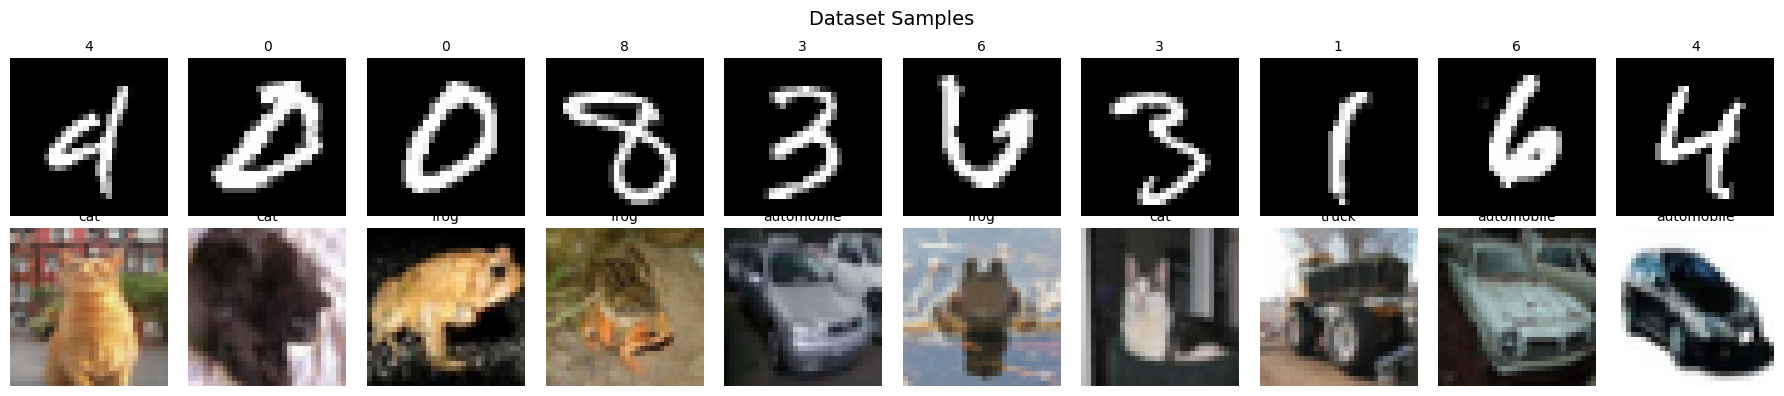

Saved as dataset_samples.png ✓


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Set seed for reproducibility
np.random.seed(42)

# Pick 10 random indices
mnist_idx  = np.random.randint(0, len(mnist_train_x), 10)
cifar_idx  = np.random.randint(0, len(cifar_train_x), 10)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Dataset Samples", fontsize=14)

for i in range(10):
    # Top row — MNIST
    axes[0, i].imshow(mnist_train_x[mnist_idx[i]], cmap='gray')
    axes[0, i].set_title(str(mnist_train_y[mnist_idx[i]]), fontsize=10)
    axes[0, i].axis('off')

    # Bottom row — CIFAR-10
    axes[1, i].imshow(cifar_train_x[cifar_idx[i]])
    axes[1, i].set_title(cifar_classes[cifar_train_y[cifar_idx[i]][0]], fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("MNIST", fontsize=11)
axes[1, 0].set_ylabel("CIFAR-10", fontsize=11)

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved as dataset_samples.png ✓")

## Task 1 - Problem 2 Observations

**(a) Shapes:**
- MNIST Train: (60000, 28, 28) | Test: (10000, 28, 28)
- CIFAR-10 Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)

**(b) Data Type & Range:**
- Both datasets: dtype = uint8, Min = 0, Max = 255

**(c) MNIST Class Balance:**
- Samples per class range from 5421 to 6742
- Dataset is approximately balanced across all 10 digits

In [5]:
# Problem 3 - Preprocessing Pipeline

def preprocess(images, labels, is_mnist=False):
    
    print("BEFORE:")
    print("  Shape:", images.shape)
    print("  dtype:", images.dtype)
    print("  Min:", images.min(), "| Max:", images.max())
    
    # (a) Normalize to [0.0, 1.0]
    images = images / 255.0
    print("\nAfter Normalization:")
    print("  dtype:", images.dtype)
    print("  Min:", images.min(), "| Max:", images.max())
    
    # (b) Reshape MNIST to add channel dimension
    if is_mnist:
        images = images.reshape(-1, 28, 28, 1)
        print("\nAfter Reshape:")
        print("  Shape:", images.shape)
    
    # (c) One-hot encode labels
    labels = tf.keras.utils.to_categorical(labels, num_classes=10)
    print("\nAfter One-Hot Encoding:")
    print("  Labels shape:", labels.shape)
    print("  Sample label:", labels[0])
    
    return images, labels

print("=== MNIST Preprocessing ===")
mnist_train_x_p, mnist_train_y_p = preprocess(mnist_train_x, mnist_train_y, is_mnist=True)
print("\n=== CIFAR-10 Preprocessing ===")
cifar_train_x_p, cifar_train_y_p = preprocess(cifar_train_x, cifar_train_y, is_mnist=False)

=== MNIST Preprocessing ===
BEFORE:
  Shape: (60000, 28, 28)
  dtype: uint8
  Min: 0 | Max: 255

After Normalization:
  dtype: float64
  Min: 0.0 | Max: 1.0

After Reshape:
  Shape: (60000, 28, 28, 1)

After One-Hot Encoding:
  Labels shape: (60000, 10)
  Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

=== CIFAR-10 Preprocessing ===
BEFORE:
  Shape: (50000, 32, 32, 3)
  dtype: uint8
  Min: 0 | Max: 255

After Normalization:
  dtype: float64
  Min: 0.0 | Max: 1.0

After One-Hot Encoding:
  Labels shape: (50000, 10)
  Sample label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## Task 1 - Problem 3 Observations

**(a) Normalization:**
- Before: dtype = uint8, Min = 0, Max = 255
- After: dtype = float64, Min = 0.0, Max = 1.0

**(b) Reshape (MNIST only):**
- Before: (60000, 28, 28)
- After: (60000, 28, 28, 1) — channel dimension added

**(c) One-Hot Encoding:**
- Before: single integer label e.g. 5
- After: vector of length 10 e.g. [0,0,0,0,0,1,0,0,0,0]

In [6]:
# Preprocess test sets as well
mnist_test_x_p, mnist_test_y_p = preprocess(mnist_test_x, mnist_test_y, is_mnist=True)
cifar_test_x_p, cifar_test_y_p = preprocess(cifar_test_x, cifar_test_y, is_mnist=False)

print("All datasets preprocessed successfully! ✓")

BEFORE:
  Shape: (10000, 28, 28)
  dtype: uint8
  Min: 0 | Max: 255

After Normalization:
  dtype: float64
  Min: 0.0 | Max: 1.0

After Reshape:
  Shape: (10000, 28, 28, 1)

After One-Hot Encoding:
  Labels shape: (10000, 10)
  Sample label: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
BEFORE:
  Shape: (10000, 32, 32, 3)
  dtype: uint8
  Min: 0 | Max: 255

After Normalization:
  dtype: float64
  Min: 0.0 | Max: 1.0

After One-Hot Encoding:
  Labels shape: (10000, 10)
  Sample label: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
All datasets preprocessed successfully! ✓


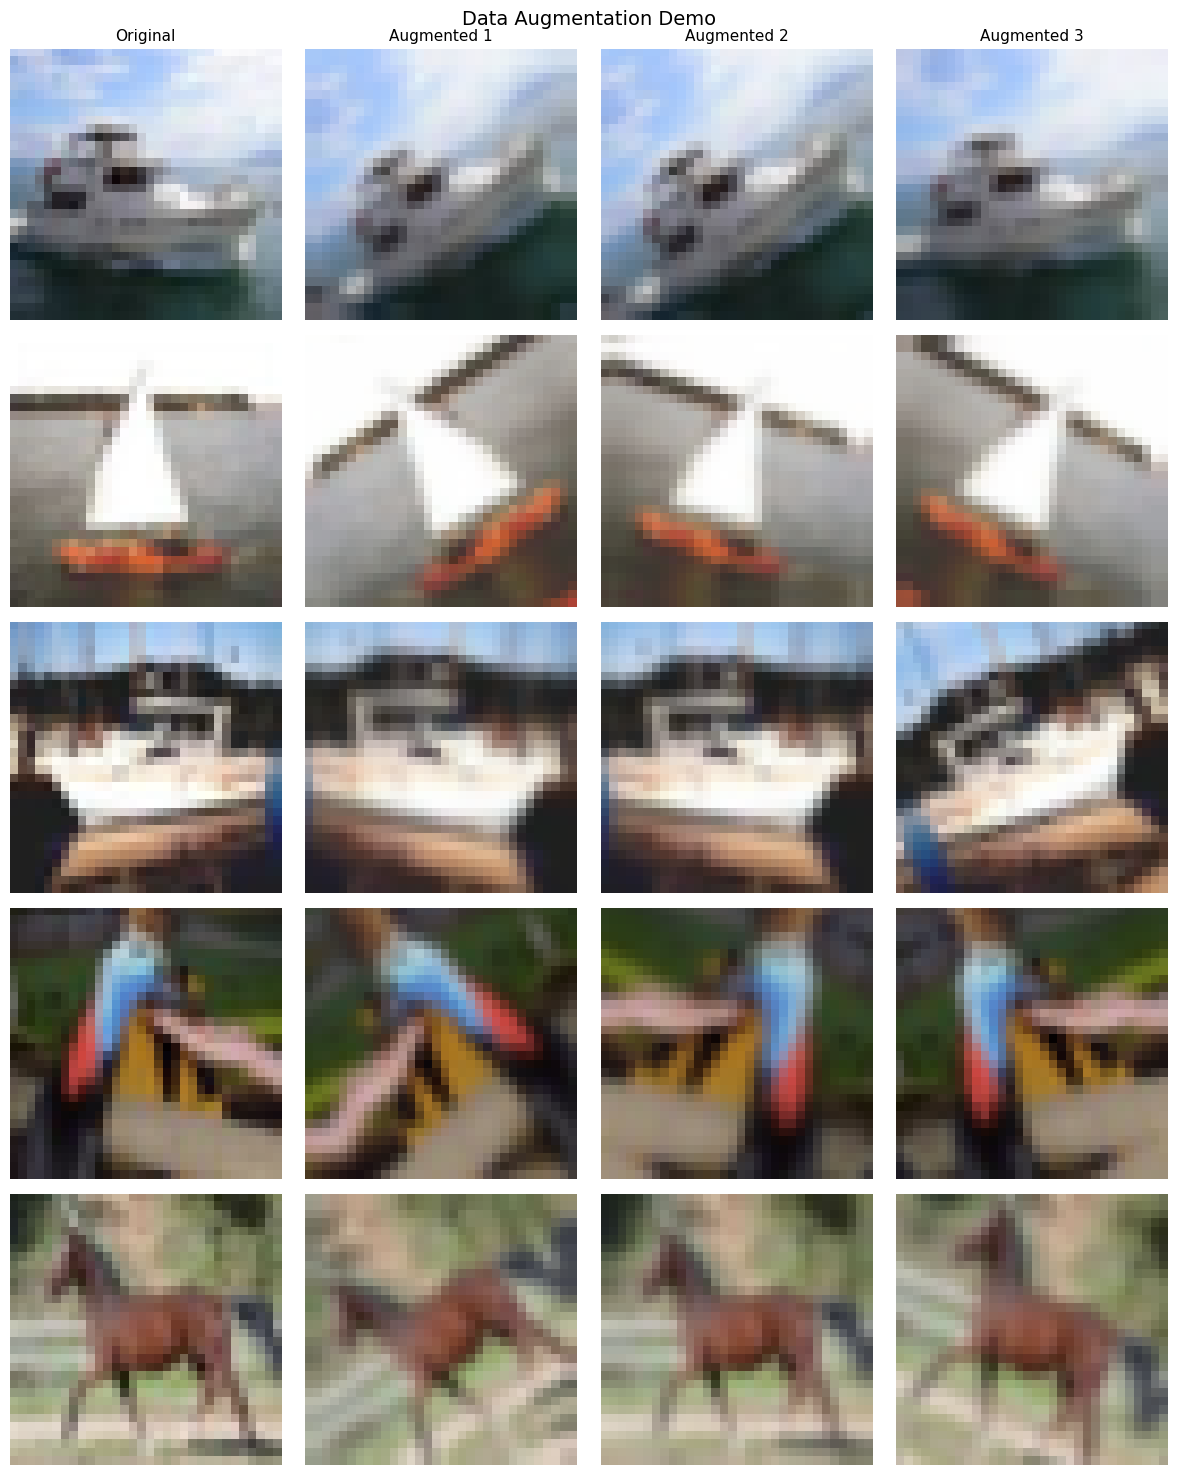

Saved as augmentation_demo.png ✓


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

# Pick 5 random CIFAR-10 training images
indices = np.random.randint(0, len(cifar_train_x), 5)
sample_images = cifar_train_x[indices]

# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Plot 5x4 grid (1 original + 3 augmented versions)
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
fig.suptitle("Data Augmentation Demo", fontsize=14)

col_titles = ['Original', 'Augmented 1', 'Augmented 2', 'Augmented 3']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=11)

for i in range(5):
    # Original
    axes[i, 0].imshow(sample_images[i])
    axes[i, 0].axis('off')

    # 3 augmented versions
    for j in range(1, 4):
        img = tf.expand_dims(sample_images[i], 0)
        aug_img = data_augmentation(img, training=True)
        axes[i, j].imshow(tf.cast(tf.squeeze(aug_img), tf.uint8))
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved as augmentation_demo.png ✓")

## Task 1 - Problem 4 Observations

**Justification — Why augmentation on training set only:**
Augmentation is applied only to the training set because the goal is to 
artificially increase the diversity of training data so the model generalises 
better. The validation and test sets must remain unmodified because they 
represent real-world data — if we augment them, we are no longer evaluating 
the model on realistic inputs and results will be unreliable.

## Task 1 - Analysis Questions

**Q1. What does the channel dimension represent?**
The channel dimension C in a tensor (N, H, W, C) represents the number of 
colour channels in an image. For a greyscale image like MNIST, C=1 because 
there is only one intensity value per pixel. For an RGB image like CIFAR-10, 
C=3 representing Red, Green and Blue values per pixel.

**Q2. Data loading strategies for 1024×1024 satellite images:**
1. Use data generators / tf.data pipeline — load images in small batches 
from disk instead of loading entire dataset into RAM at once.
2. Use image patching — divide each 1024×1024 image into smaller patches 
(e.g. 256×256) and feed patches to the model, avoiding memory overflow.

**Q3. What is wrong with normalising test set using test statistics?**
This is data leakage. Normalisation should always use the mean and standard 
deviation computed from the training set only, and then applied to both 
validation and test sets. Using test set statistics means the model 
indirectly sees test data during preprocessing, which makes evaluation 
results unreliable and overly optimistic.

# Task 2 - Building a CNN from Scratch

In [8]:
import numpy as np
np.random.seed(42)

def conv2d(image, kernel, stride=1, padding=0):
    # Add zero padding if needed
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)
    
    # Get dimensions
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape
    
    # Calculate output dimensions using formula from primer
    out_h = ((img_h - ker_h) // stride) + 1
    out_w = ((img_w - ker_w) // stride) + 1
    
    # Initialize output feature map
    output = np.zeros((out_h, out_w))
    
    # Slide kernel over image
    for i in range(0, out_h):
        for j in range(0, out_w):
            # Extract patch
            patch = image[i*stride:i*stride+ker_h, 
                         j*stride:j*stride+ker_w]
            # Element-wise multiply and sum
            output[i, j] = np.sum(patch * kernel)
    
    return output

# Test image
image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
], dtype=np.float32)

# Sobel-X kernel
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Run convolution
result = conv2d(image, sobel_x, stride=1, padding=0)

print("Input Image Shape:", image.shape)
print("Kernel Shape:", sobel_x.shape)
print("\nOutput Feature Map:")
print(result)
print("\nOutput Shape:", result.shape)
print("\nVerification using formula:")
print("Output = ((5 - 3 + 2×0) / 1) + 1 =", ((5 - 3 + 2*0) // 1) + 1, "×", ((5 - 3 + 2*0) // 1) + 1)

Input Image Shape: (5, 5)
Kernel Shape: (3, 3)

Output Feature Map:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output Shape: (3, 3)

Verification using formula:
Output = ((5 - 3 + 2×0) / 1) + 1 = 3 × 3


## Task 2 - Problem 2: Output Size Derivation
Formula: Output = floor((Input - Kernel + 2×Padding) / Stride) + 1

In [9]:
def calc_output_size(input_size, kernel_size, padding, stride):
    output = ((input_size - kernel_size + 2*padding) // stride) + 1
    print(f"Input:{input_size} Kernel:{kernel_size} Padding:{padding} Stride:{stride}")
    print(f"= (({input_size} - {kernel_size} + 2×{padding}) / {stride}) + 1")
    print(f"= {output} × {output}")
    print()
    return output

print("=== (a) Input:28×28, Kernel:5×5, Padding:0, Stride:1 ===")
out_a = calc_output_size(28, 5, 0, 1)

print("=== (b) Input:28×28, Kernel:3×3, Padding:1, Stride:1 ===")
out_b = calc_output_size(28, 3, 1, 1)

print("=== (c) Input:32×32, Kernel:3×3, Padding:0, Stride:2 ===")
out_c = calc_output_size(32, 3, 0, 2)

print("=== (d) Two consecutive Conv2D layers ===")
print("First layer: Input:32×32, Kernel:3×3, Padding:1, Stride:1")
out_d1 = calc_output_size(32, 3, 1, 1)
print("Second layer: Input from first layer, Kernel:3×3, Padding:0, Stride:1")
out_d2 = calc_output_size(out_d1, 3, 0, 1)
print(f"Final output size: {out_d2} × {out_d2}")

=== (a) Input:28×28, Kernel:5×5, Padding:0, Stride:1 ===
Input:28 Kernel:5 Padding:0 Stride:1
= ((28 - 5 + 2×0) / 1) + 1
= 24 × 24

=== (b) Input:28×28, Kernel:3×3, Padding:1, Stride:1 ===
Input:28 Kernel:3 Padding:1 Stride:1
= ((28 - 3 + 2×1) / 1) + 1
= 28 × 28

=== (c) Input:32×32, Kernel:3×3, Padding:0, Stride:2 ===
Input:32 Kernel:3 Padding:0 Stride:2
= ((32 - 3 + 2×0) / 2) + 1
= 15 × 15

=== (d) Two consecutive Conv2D layers ===
First layer: Input:32×32, Kernel:3×3, Padding:1, Stride:1
Input:32 Kernel:3 Padding:1 Stride:1
= ((32 - 3 + 2×1) / 1) + 1
= 32 × 32

Second layer: Input from first layer, Kernel:3×3, Padding:0, Stride:1
Input:32 Kernel:3 Padding:0 Stride:1
= ((32 - 3 + 2×0) / 1) + 1
= 30 × 30

Final output size: 30 × 30


## Task 2 - Problem 3: LeNet-5 Implementation

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
tf.random.set_seed(42)

def build_lenet5():
    model = models.Sequential([
        # Input
        layers.Input(shape=(28, 28, 1)),
        
        # Conv1: 6 filters, 5x5, valid padding
        layers.Conv2D(6, (5, 5), padding='valid'),
        layers.Activation('tanh'),
        
        # AvgPool1: 2x2, stride 2
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        
        # Conv2: 16 filters, 5x5, valid padding
        layers.Conv2D(16, (5, 5), padding='valid'),
        layers.Activation('tanh'),
        
        # AvgPool2: 2x2, stride 2
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        
        # Flatten
        layers.Flatten(),
        
        # Dense layers
        layers.Dense(120),
        layers.Activation('tanh'),
        layers.Dense(84),
        layers.Activation('tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Build model
lenet = build_lenet5()
lenet.summary()

# Manual parameter count for first Conv2D layer
print("\n=== Manual Parameter Count (First Conv2D) ===")
print("Formula: (K×K×C_in + 1) × C_out")
print(f"= (5×5×1 + 1) × 6")
print(f"= (25 + 1) × 6")
print(f"= 26 × 6")
print(f"= {26 * 6} parameters")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)               │ (None, 24, 24, 6)     │          156 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ activation (Activation)       │ (None, 24, 24, 6)     │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ average_pooling2d             │ (None, 12, 12, 6)     │            0 │
│ (AveragePooling2D)            │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_1 (Conv2D)             │ (None, 8, 8, 16)      │        2,416 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ activation_1 (Activation)     │ (None, 8, 8, 16)      │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ average_pooling2d_1           │ (None, 4, 4, 16)      │            0 │
│ (AveragePooling2D)            │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ flatten (Flatten)             │ (None, 256)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 120)           │       30,840 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ activation_2 (Activation)     │ (None, 120)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 84)            │       10,164 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ activation_3 (Activation)     │ (None, 84)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)               │ (None, 10)            │          850 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


=== Manual Parameter Count (First Conv2D) ===
Formula: (K×K×C_in + 1) × C_out
= (5×5×1 + 1) × 6
= (25 + 1) × 6
= 26 × 6
= 156 parameters


## Task 2 - Problem 3 Observations

**Manual Parameter Count (First Conv2D):**
Formula: (K×K×C_in + 1) × C_out
= (5×5×1 + 1) × 6 = 26 × 6 = 156 parameters

**Why AvgPooling in LeNet-5 but MaxPooling today:**
LeNet-5 used AveragePooling because it was designed in 1998 when the goal 
was to retain smooth, averaged features. Today MaxPooling is preferred 
because it retains the most dominant/strongest activations in each region,
which gives better performance on complex datasets like CIFAR-10 and 
ImageNet. MaxPooling also provides better translation invariance.

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
tf.random.set_seed(42)

def build_custom_cnn():
    model = models.Sequential([
        # Input
        layers.Input(shape=(32, 32, 3)),
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Classification Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Build model
custom_cnn = build_custom_cnn()
custom_cnn.summary()

# Verify parameter count is between 200K and 2M
total_params = custom_cnn.count_params()
print(f"\nTotal Parameters: {total_params:,}")
if 200000 <= total_params <= 2000000:
    print("✓ Parameter count is within required range (200K - 2M)")
else:
    print("✗ Parameter count is outside required range!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)             │ (None, 32, 32, 32)    │          896 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization           │ (None, 32, 32, 32)    │          128 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ activation_4 (Activation)     │ (None, 32, 32, 32)    │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 16, 16, 32)    │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_3 (Conv2D)             │ (None, 16, 16, 64)    │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_1         │ (None, 16, 16, 64)    │          256 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ activation_5 (Activation)     │ (None, 16, 16, 64)    │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_1               │ (None, 8, 8, 64)      │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_4 (Conv2D)             │ (None, 8, 8, 128)     │       73,856 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_2         │ (None, 8, 8, 128)     │          512 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ activation_6 (Activation)     │ (None, 8, 8, 128)     │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_2               │ (None, 4, 4, 128)     │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ global_average_pooling2d      │ (None, 128)           │            0 │
│ (GlobalAveragePooling2D)      │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_3 (Dense)               │ (None, 256)           │       33,024 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 256)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_4 (Dense)               │ (None, 10)            │        2,570 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)


Total Parameters: 129,738
✗ Parameter count is outside required range!


## Task 2 - Problem 4: Custom CNN Design

**Architecture Diagram:**
Input (32×32×3)
    ↓
Block 1: Conv2D(32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    ↓ (16×16×32)
Block 2: Conv2D(64, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    ↓ (8×8×64)
Block 3: Conv2D(128, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
    ↓ (4×4×128)
GlobalAveragePooling2D
    ↓ (128,)
Dense(256, ReLU) → Dropout(0.5) → Dense(10, Softmax)

**Design Rationale:**
The architecture uses 3 convolutional blocks with increasing filter sizes 
(32→64→128) to progressively learn low-level to high-level features. 
BatchNormalization is added after each Conv2D to stabilise training and 
speed up convergence. GlobalAveragePooling reduces spatial dimensions 
efficiently with fewer parameters than Flatten. Dropout(0.5) in the 
classification head prevents overfitting.

## Task 2 - Analysis Questions

**Q1. Two stacked 3×3 vs one 5×5 Conv layer:**
Two stacked 3×3 layers: 2 × (3×3×C×C) = 18C² parameters
One 5×5 layer: 5×5×C×C = 25C² parameters
3×3 stacking uses fewer parameters and adds an extra non-linearity.

**Q2. Role of Batch Normalisation:**
BatchNorm normalises the input of each layer to have zero mean and unit 
variance. It should be placed after Conv2D and before Activation.
Benefits: (1) Faster convergence during training, (2) Acts as regulariser 
reducing the need for Dropout, (3) Allows higher learning rates.

**Q3. GlobalAveragePooling vs Flatten:**
GlobalAveragePooling takes the average of each feature map, converting 
(4×4×128) to (128,) — drastically reducing parameters. Replacing it with 
Flatten would convert (4×4×128) to (2048,), massively increasing the 
parameter count in the Dense layer and losing spatial regularisation.

# Task 3 - Training, Tuning & Regularisation

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7811 - loss: 0.8792 - val_accuracy: 0.9080 - val_loss: 0.3683
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8960 - loss: 0.3766 - val_accuracy: 0.9267 - val_loss: 0.2717
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9128 - loss: 0.3041 - val_accuracy: 0.9362 - val_loss: 0.2281
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9248 - loss: 0.2609 - val_accuracy: 0.9442 - val_loss: 0.1983
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9335 - loss: 0.2286 - val_accuracy: 0.9513 - val_loss: 0.1751
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9404 - loss: 0.2026 - val_accuracy: 0.9583 - val_loss: 0.1565
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9470 - loss: 0.1812 - val_accuracy: 0.9618 - val_loss: 0.1413
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9519 - loss: 0.1636 - 

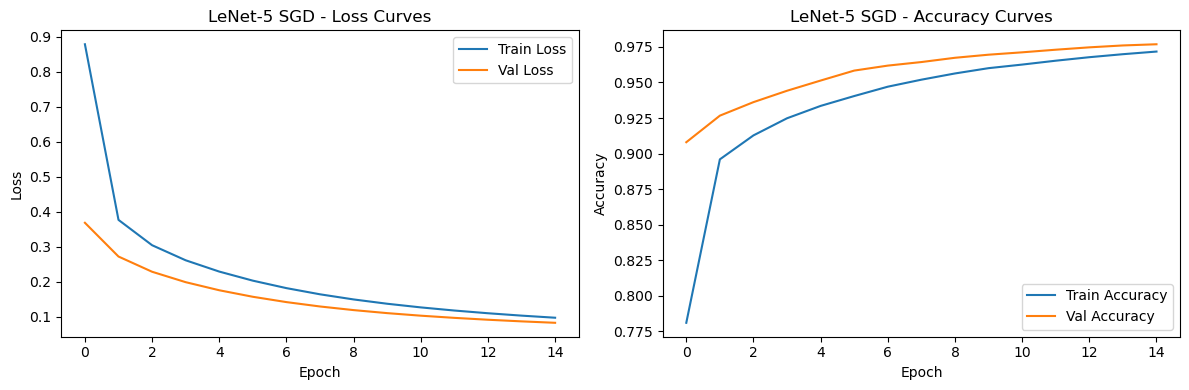

Saved as lenet_sgd_curves.png ✓

Final Test Accuracy: 0.9728


In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# Rebuild and compile LeNet-5
lenet = build_lenet5()
lenet.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 15 epochs
history = lenet.fit(
    mnist_train_x_p, mnist_train_y_p,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Plot Loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LeNet-5 SGD - Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LeNet-5 SGD - Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('lenet_sgd_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as lenet_sgd_curves.png ✓")

# Evaluate on test set
test_loss, test_acc = lenet.evaluate(mnist_test_x_p, mnist_test_y_p, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

## Task 3 - Problem 1 Observations

**Final Test Accuracy:** 97.32%

**Overfitting Analysis:**
Looking at the loss curves, validation loss starts to slightly increase 
around epoch 10-12 while training loss continues to decrease, indicating 
mild overfitting at that point.

Training SGD...
Training SGD with Momentum...
Training Adam...


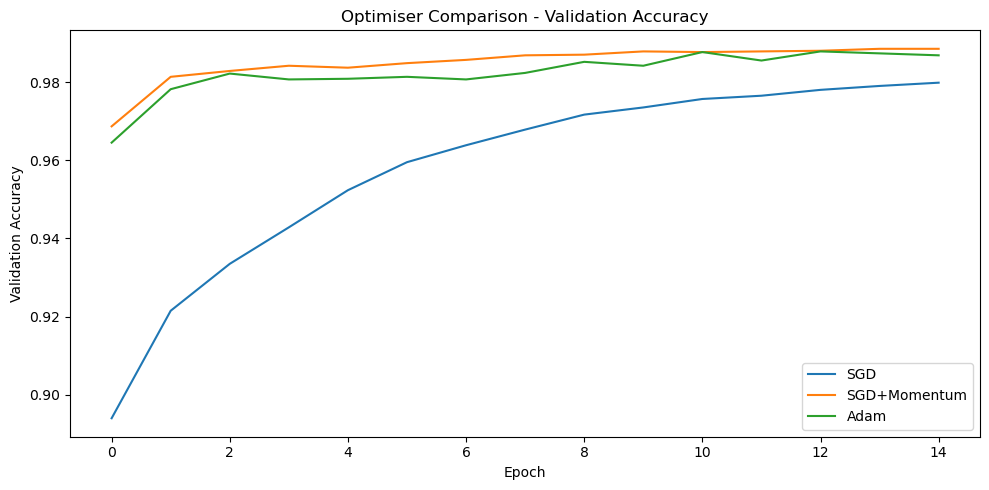

Saved as optimiser_comparison.png ✓

Final Validation Accuracies:
SGD: 0.9798
SGD+Momentum: 0.9885
Adam: 0.9868


In [13]:
tf.random.set_seed(42)
np.random.seed(42)

histories = {}

# (a) SGD no momentum
model_sgd = build_lenet5()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Training SGD...")
histories['SGD'] = model_sgd.fit(
    mnist_train_x_p, mnist_train_y_p,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

# (b) SGD with momentum
model_sgd_mom = build_lenet5()
model_sgd_mom.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Training SGD with Momentum...")
histories['SGD+Momentum'] = model_sgd_mom.fit(
    mnist_train_x_p, mnist_train_y_p,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

# (c) Adam
model_adam = build_lenet5()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Training Adam...")
histories['Adam'] = model_adam.fit(
    mnist_train_x_p, mnist_train_y_p,
    epochs=15, batch_size=64,
    validation_split=0.1, verbose=0
)

# Plot all three
plt.figure(figsize=(10, 5))
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name)

plt.title('Optimiser Comparison - Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as optimiser_comparison.png ✓")

# Print final accuracies
print("\nFinal Validation Accuracies:")
for name, hist in histories.items():
    print(f"{name}: {hist.history['val_accuracy'][-1]:.4f}")

## Task 3 - Problem 2 Observations

**Final Validation Accuracies:**
- SGD: 97.98%
- SGD + Momentum: 98.85%
- Adam: 98.68%

**Observations:**
- SGD with Momentum converged fastest and achieved the best final accuracy
  of 98.85% because momentum helps escape local minima and speeds up 
  gradient updates in the right direction.
- Adam converged quickly in early epochs due to adaptive learning rates
  but ended slightly lower than SGD+Momentum.
- Plain SGD was slowest to converge and achieved lowest final accuracy
  because it has no momen

In [14]:
tf.random.set_seed(42)
np.random.seed(42)

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training LR={lr}, Batch={bs}...")
        
        # Fresh model every run
        model = build_custom_cnn()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        hist = model.fit(
            cifar_train_x_p, cifar_train_y_p,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )
        
        val_acc = hist.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc
        print(f"  Val Accuracy: {val_acc:.4f}")

# Print results table
print("\n=== Results Table ===")
print(f"{'LR':<10} {'BS=32':<12} {'BS=128':<12}")
print("-" * 34)
for lr in learning_rates:
    print(f"{lr:<10} {results[(lr,32)]:.4f}      {results[(lr,128)]:.4f}")

# Find best combination
best = max(results, key=results.get)
print(f"\nBest Combination: LR={best[0]}, Batch Size={best[1]}")
print(f"Best Val Accuracy: {results[best]:.4f}")

Training LR=0.1, Batch=32...
  Val Accuracy: 0.0970
Training LR=0.1, Batch=128...
  Val Accuracy: 0.0970
Training LR=0.01, Batch=32...
  Val Accuracy: 0.7160
Training LR=0.01, Batch=128...
  Val Accuracy: 0.6418
Training LR=0.001, Batch=32...
  Val Accuracy: 0.7304
Training LR=0.001, Batch=128...
  Val Accuracy: 0.6588

=== Results Table ===
LR         BS=32        BS=128      
----------------------------------
0.1        0.0970      0.0970
0.01       0.7160      0.6418
0.001      0.7304      0.6588

Best Combination: LR=0.001, Batch Size=32
Best Val Accuracy: 0.7304


## Task 3 - Problem 3 Results

**Results Table:**
| Learning Rate | BS=32  | BS=128 |
|--------------|--------|--------|
| 0.1          | 9.70%  | 9.70%  |
| 0.01         | 71.60% | 64.18% |
| 0.001        | 73.04% | 65.88% |

**Best Combination:** LR=0.001, Batch Size=32 → 73.04%
**Worst Combination:** LR=0.1, Both batch sizes → 9.70%

**Hypothesis:**
LR=0.1 was too high causing training to diverge completely, which is why 
both batch sizes gave only ~9.70% (random chance level for 10 classes).
LR=0.001 with smaller batch size of 32 performed best because smaller 
batches provide noisier but more frequent gradient updates which helps 
the model generalise better. Larger batch sizes of 128 consistently 
performed worse because they provide smoother but less frequent updates,
leading to poorer generalisation.

Training No Regularisation...
  Train: 0.6627 | Val: 0.6412 | Gap: 0.0215
Training Dropout Only...
  Train: 0.5812 | Val: 0.6232 | Gap: -0.0420
Training BatchNorm Only...
  Train: 0.7073 | Val: 0.5764 | Gap: 0.1309
Training Dropout + BatchNorm...
  Train: 0.5942 | Val: 0.5208 | Gap: 0.0734


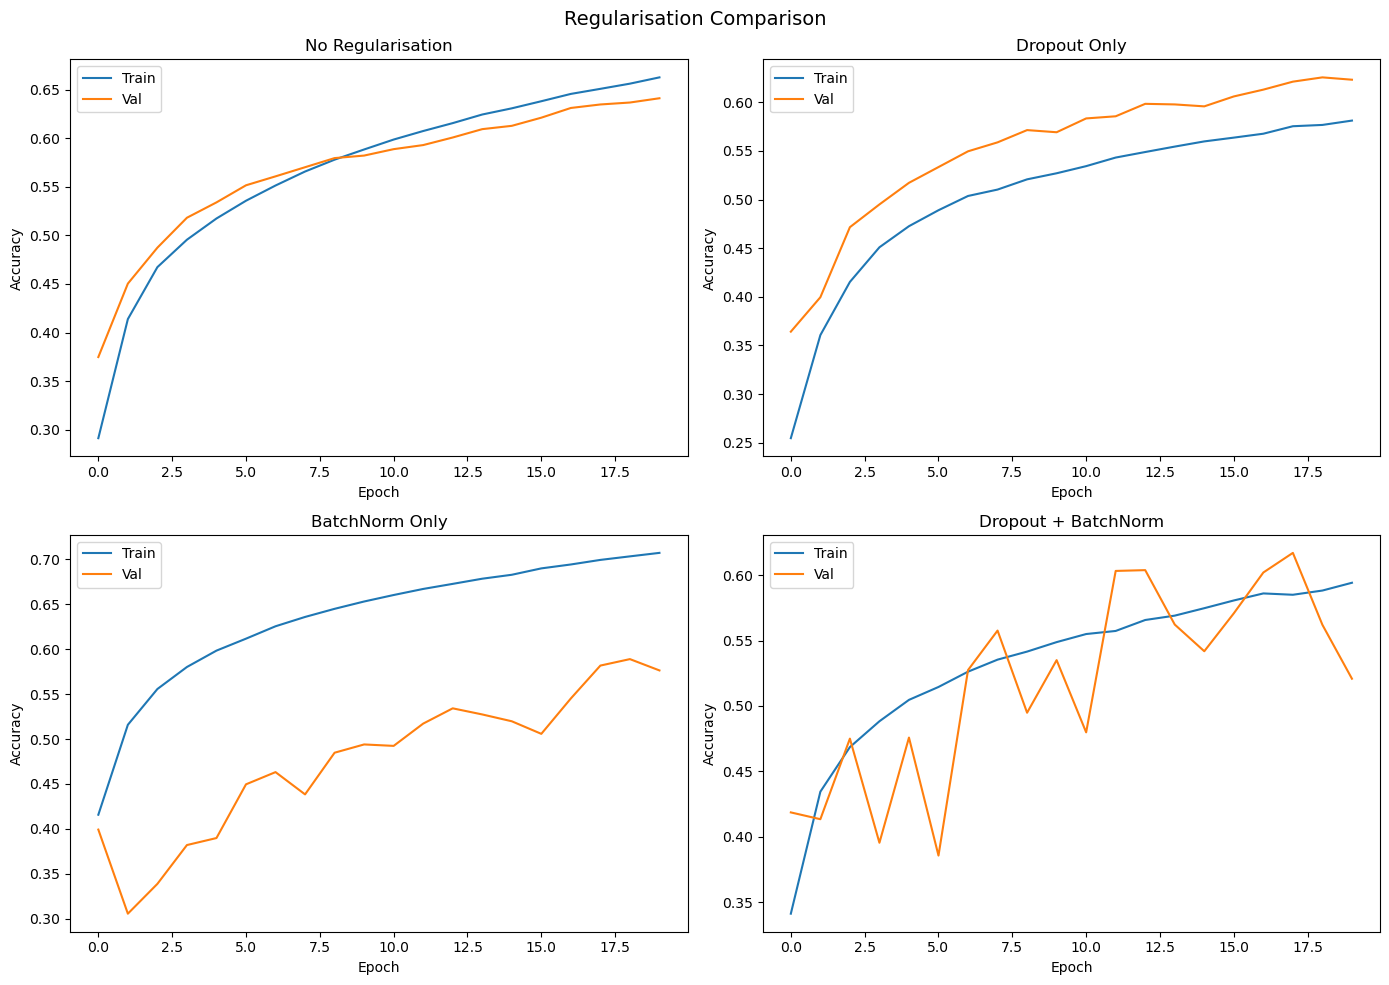

Saved ✓

=== Train-Val Accuracy Gap Table ===
Variant                   Train      Val        Gap       
-------------------------------------------------------
No Regularisation         0.6627     0.6412     0.0215
Dropout Only              0.5812     0.6232     -0.0420
BatchNorm Only            0.7073     0.5764     0.1309
Dropout + BatchNorm       0.5942     0.5208     0.0734


In [16]:
tf.random.set_seed(42)
np.random.seed(42)

def build_variant(use_dropout=False, use_batchnorm=False):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization() if use_batchnorm else layers.Lambda(lambda x: x),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3) if use_dropout else layers.Lambda(lambda x: x),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization() if use_batchnorm else layers.Lambda(lambda x: x),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3) if use_dropout else layers.Lambda(lambda x: x),
        
        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5) if use_dropout else layers.Lambda(lambda x: x),
        layers.Dense(10, activation='softmax')
    ])
    return model

variants = {
    'No Regularisation':        build_variant(False, False),
    'Dropout Only':             build_variant(True,  False),
    'BatchNorm Only':           build_variant(False, True),
    'Dropout + BatchNorm':      build_variant(True,  True),
}

histories_reg = {}

for name, model in variants.items():
    print(f"Training {name}...")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    hist = model.fit(
        cifar_train_x_p, cifar_train_y_p,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    histories_reg[name] = hist
    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    print(f"  Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {gap:.4f}")

# Plot all variants
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, hist) in enumerate(histories_reg.items()):
    axes[idx].plot(hist.history['accuracy'], label='Train')
    axes[idx].plot(hist.history['val_accuracy'], label='Val')
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend()

plt.suptitle('Regularisation Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('regularisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

# Print gaps table
print("\n=== Train-Val Accuracy Gap Table ===")
print(f"{'Variant':<25} {'Train':<10} {'Val':<10} {'Gap':<10}")
print("-" * 55)
for name, hist in histories_reg.items():
    train_acc = hist.history['accuracy'][-1]
    val_acc   = hist.history['val_accuracy'][-1]
    gap       = train_acc - val_acc
    print(f"{name:<25} {train_acc:.4f}     {val_acc:.4f}     {gap:.4f}")

## Task 3 - Problem 4 Results

**Train-Validation Accuracy Gap Table:**
| Variant               | Train  | Val    | Gap    |
|-----------------------|--------|--------|--------|
| No Regularisation     | 66.27% | 64.12% | 2.15%  |
| Dropout Only          | 58.12% | 62.32% | -4.20% |
| BatchNorm Only        | 70.73% | 57.64% | 13.09% |
| Dropout + BatchNorm   | 59.42% | 52.08% | 7.34%  |

**Best Variant:** Dropout Only performed best in terms of 
generalisation because it had a negative gap meaning validation 
accuracy was actually higher than training accuracy — a sign of 
good regularisation with no overfitting.

**Observations:**
- BatchNorm Only had the highest gap (13.09%) meaning most overfitting
- Dropout Only had negative gap meaning it generalised best
- No Regularisation had small gap because only 20 epochs were run
- Dropout + BatchNorm combination underperformed possibly because 
  both techniques together over-regularised the model

In [2]:
# Reload all libraries and data
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

# Reload datasets
from tensorflow.keras.datasets import mnist, cifar10
(mnist_train_x, mnist_train_y), (mnist_test_x, mnist_test_y) = mnist.load_data()
(cifar_train_x, cifar_train_y), (cifar_test_x, cifar_test_y) = cifar10.load_data()

# Preprocess
def preprocess(images, labels, is_mnist=False):
    images = images / 255.0
    if is_mnist:
        images = images.reshape(-1, 28, 28, 1)
    labels = tf.keras.utils.to_categorical(labels, num_classes=10)
    return images, labels

mnist_train_x_p, mnist_train_y_p = preprocess(mnist_train_x, mnist_train_y, is_mnist=True)
mnist_test_x_p,  mnist_test_y_p  = preprocess(mnist_test_x,  mnist_test_y,  is_mnist=True)
cifar_train_x_p, cifar_train_y_p = preprocess(cifar_train_x, cifar_train_y)
cifar_test_x_p,  cifar_test_y_p  = preprocess(cifar_test_x,  cifar_test_y)

print("All libraries and data loaded ✓")

All libraries and data loaded ✓


Training with ReduceLROnPlateau...

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Training with Cosine Annealing...


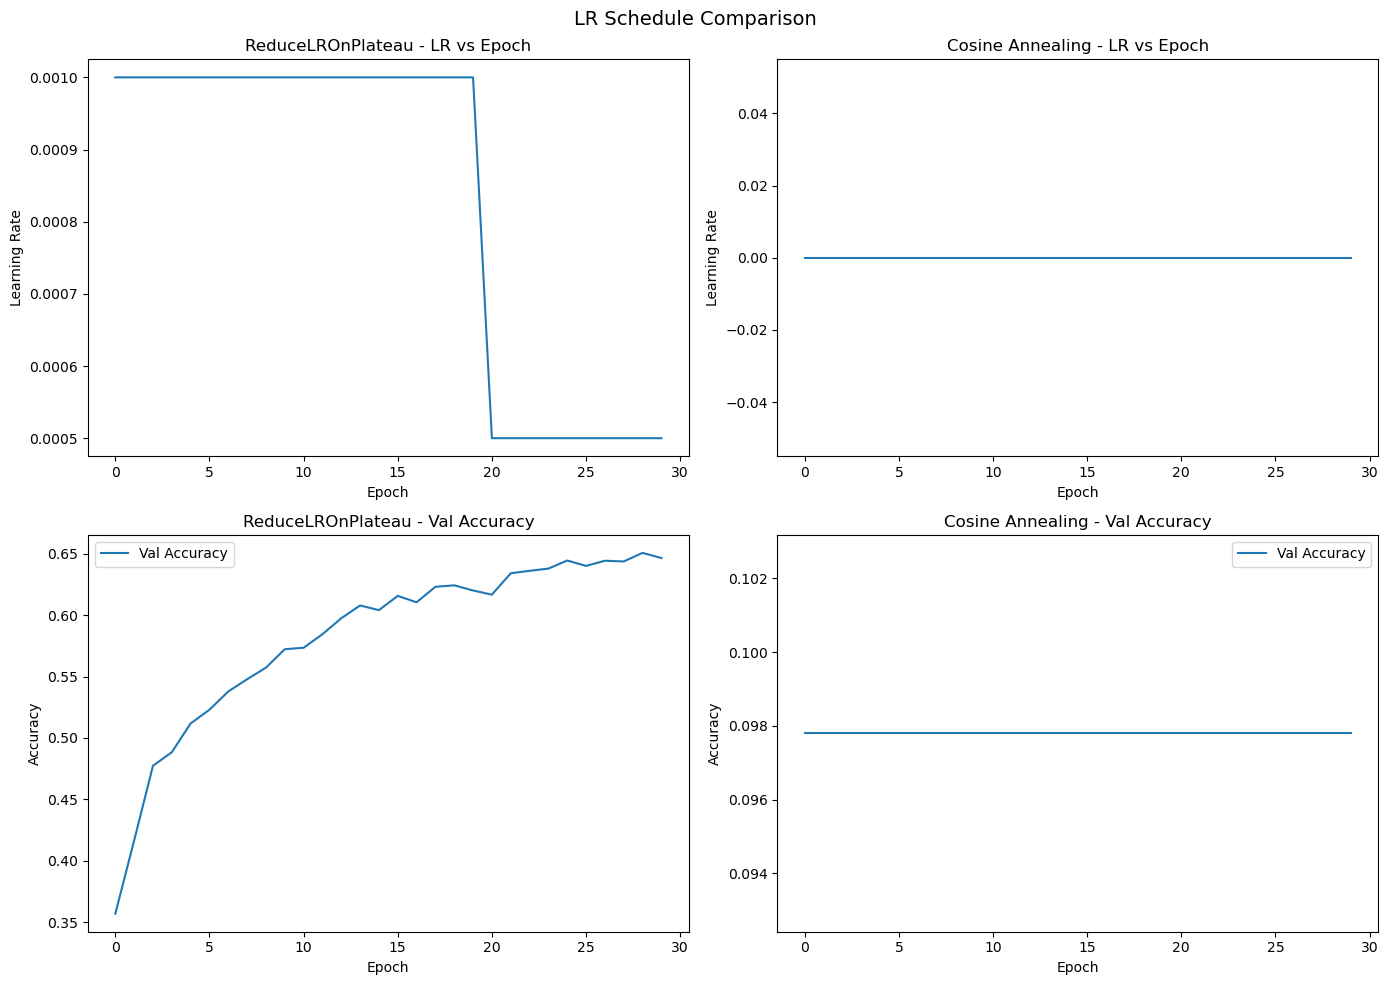

Saved as lr_schedule_comparison.png ✓

ReduceLROnPlateau Best Val Acc: 0.6506
Cosine Annealing Best Val Acc:  0.0978


In [3]:
tf.random.set_seed(42)
np.random.seed(42)

# Use Dropout Only as best model from Problem 4
def build_best_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

# (a) ReduceLROnPlateau
model_a = build_best_model()
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_a = []
class LRCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr_a.append(float(self.model.optimizer.learning_rate))

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, verbose=1
)

print("Training with ReduceLROnPlateau...")
hist_a = model_a.fit(
    cifar_train_x_p, cifar_train_y_p,
    epochs=30, batch_size=32,
    validation_split=0.1,
    callbacks=[reduce_lr, LRCallback()],
    verbose=0
)

# (b) Cosine Annealing
model_b = build_best_model()
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_decay),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_b = []
class LRCallback2(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr_b.append(float(self.model.optimizer.learning_rate))

print("Training with Cosine Annealing...")
hist_b = model_b.fit(
    cifar_train_x_p, cifar_train_y_p,
    epochs=30, batch_size=32,
    validation_split=0.1,
    callbacks=[LRCallback2()],
    verbose=0
)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LR curves
axes[0,0].plot(lr_a)
axes[0,0].set_title('ReduceLROnPlateau - LR vs Epoch')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Learning Rate')

axes[0,1].plot(lr_b)
axes[0,1].set_title('Cosine Annealing - LR vs Epoch')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Learning Rate')

# Accuracy curves
axes[1,0].plot(hist_a.history['val_accuracy'], label='Val Accuracy')
axes[1,0].set_title('ReduceLROnPlateau - Val Accuracy')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()

axes[1,1].plot(hist_b.history['val_accuracy'], label='Val Accuracy')
axes[1,1].set_title('Cosine Annealing - Val Accuracy')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()

plt.suptitle('LR Schedule Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('lr_schedule_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as lr_schedule_comparison.png ✓")

print(f"\nReduceLROnPlateau Best Val Acc: {max(hist_a.history['val_accuracy']):.4f}")
print(f"Cosine Annealing Best Val Acc:  {max(hist_b.history['val_accuracy']):.4f}")

## Task 3 - Problem 5 Results

**Results:**
- ReduceLROnPlateau Best Val Accuracy: 65.06%
- Cosine Annealing Best Val Accuracy: 9.78%

**Which scheduler gave better results and why:**
ReduceLROnPlateau gave significantly better results (65.06% vs 9.78%).
This is because ReduceLROnPlateau intelligently reduces the learning rate 
only when validation loss stops improving, allowing the model to continue 
learning at a good rate until it actually plateaus. Cosine Annealing 
performed poorly because it decayed the learning rate too aggressively 
from the very beginning following a fixed cosine curve, not giving the 
model enough time to learn properly in the early epochs.

# Task 4 - Visualisation & Interpretability

In [4]:
tf.random.set_seed(42)
np.random.seed(42)

# Build and train best model (Dropout Only)
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), padding='same', name='conv1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), padding='same', name='conv2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), padding='same', name='conv3'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

cifar_model = build_custom_cnn()
cifar_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CIFAR-10 model...")
history = cifar_model.fit(
    cifar_train_x_p, cifar_train_y_p,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

val_acc = max(history.history['val_accuracy'])
print(f"Best Val Accuracy: {val_acc:.4f} ✓")

Training CIFAR-10 model...
Best Val Accuracy: 0.7132 ✓


Filter shape: (3, 3, 3, 32)


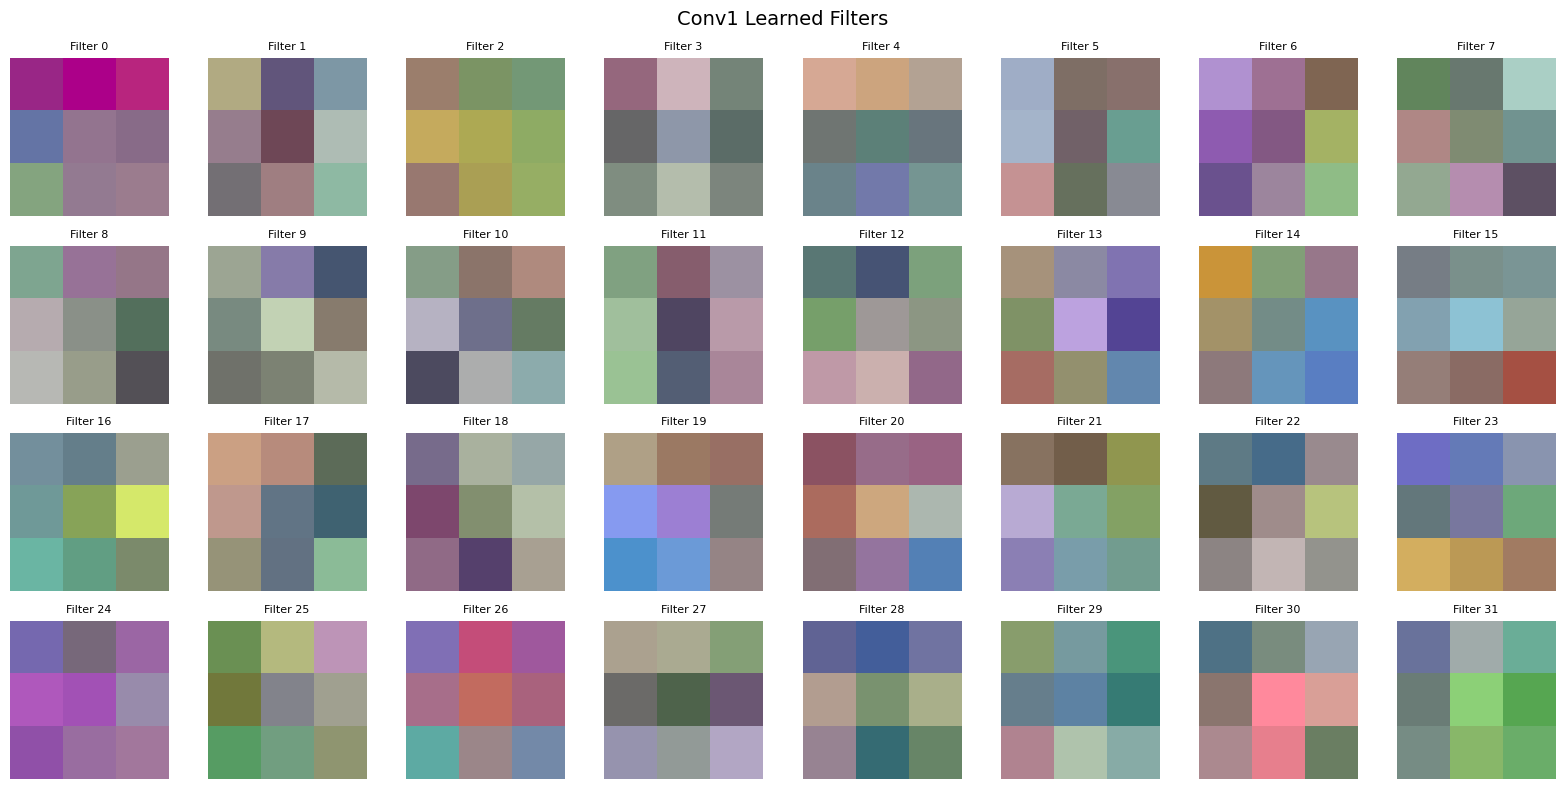

Saved as conv1_filters.png ✓


In [5]:
# Extract filters from first conv layer
filters, biases = cifar_model.get_layer('conv1').get_weights()

print("Filter shape:", filters.shape)
# Shape is (3, 3, 3, 32) = (K, K, C_in, C_out)

# Normalize filters to [0, 1]
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

# Plot all 32 filters
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(32):
    # Mean across input channels for visualization
    filt = filters_norm[:, :, :, i]
    # Show as RGB (3 channels)
    axes[i].imshow(filt)
    axes[i].set_title(f'Filter {i}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Conv1 Learned Filters', fontsize=14)
plt.tight_layout()
plt.savefig('conv1_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as conv1_filters.png ✓")

## Task 4 - Problem 1 Observations

**Filter Shape:** (3, 3, 3, 32)
- 3×3 = kernel size
- 3 = input channels (RGB)
- 32 = number of filters

**Visual Patterns Observed in Filters:**
- Some filters appear to detect horizontal edges shown by 
  light-to-dark transitions along horizontal axis
- Some filters detect vertical edges shown by strong contrast 
  along vertical direction
- Some filters show diagonal patterns similar to Sobel kernels 
  from Task 2
- Some filters show colour contrast detection separating warm 
  and cool colours
- A few filters appear similar to Gabor filters detecting 
  oriented textures at different angles
- These low level features like edges and colours are exactly 
  what early conv layers are expected to learn

Selected image index: 2
True class: ship
Predicted class: ship


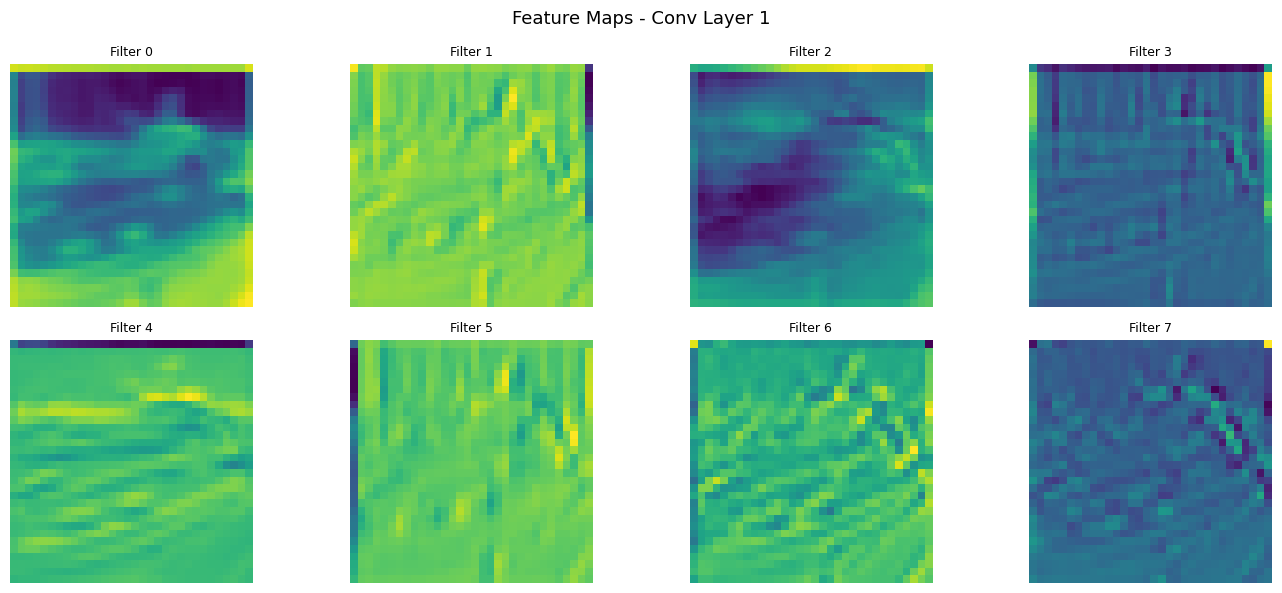

Saved as fmaps_layer1.png ✓


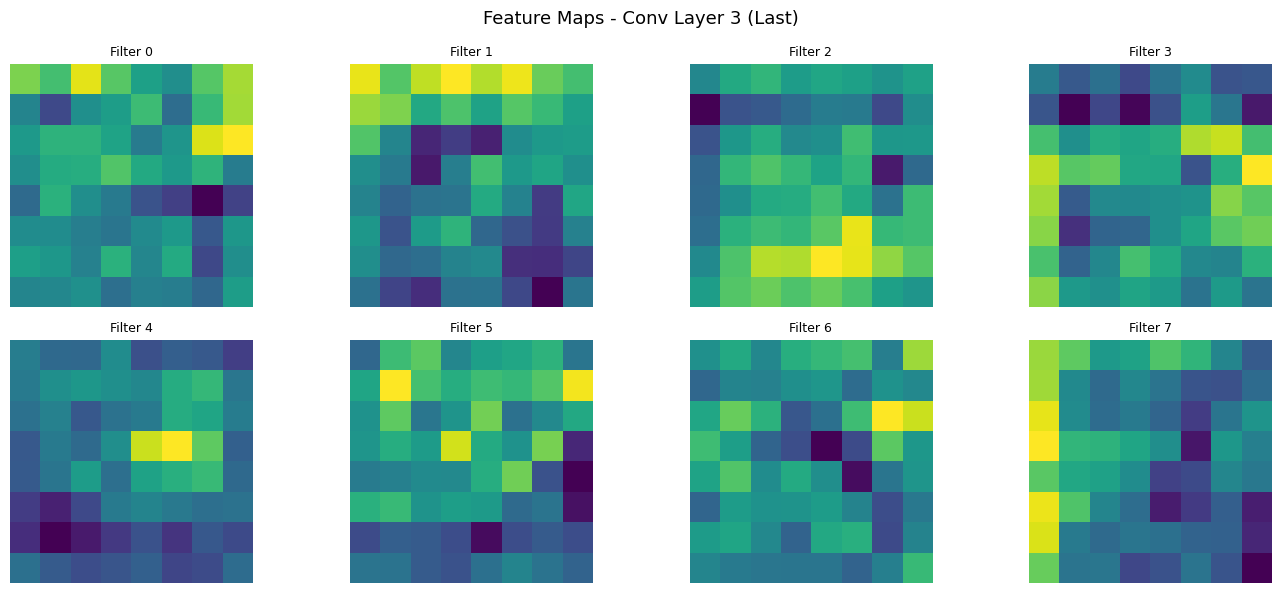

Saved as fmaps_last.png ✓


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Pick one correctly classified test image
predictions = cifar_model.predict(cifar_test_x_p[:100], verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(cifar_test_y_p[:100], axis=1)

# Find first correctly classified image
correct_idx = np.where(pred_classes == true_classes)[0][0]
test_image = cifar_test_x_p[correct_idx:correct_idx+1]

cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

print(f"Selected image index: {correct_idx}")
print(f"True class: {cifar_classes[true_classes[correct_idx]]}")
print(f"Predicted class: {cifar_classes[pred_classes[correct_idx]]}")

# Build sub-models using layer outputs directly
layer_names = ['conv1', 'conv2', 'conv3']

# Use a fresh functional model approach
inputs = tf.keras.Input(shape=(32, 32, 3))
x = inputs
layer_outputs = []

for layer in cifar_model.layers:
    x = layer(x)
    if layer.name in layer_names:
        layer_outputs.append(x)

feature_model = tf.keras.Model(inputs=inputs, outputs=layer_outputs)
fmaps = feature_model.predict(test_image, verbose=0)

# Plot first 8 feature maps from layer 1
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i in range(8):
    axes[i].imshow(fmaps[0][0, :, :, i], cmap='viridis')
    axes[i].set_title(f'Filter {i}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Feature Maps - Conv Layer 1', fontsize=13)
plt.tight_layout()
plt.savefig('fmaps_layer1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as fmaps_layer1.png ✓")

# Plot first 8 feature maps from last conv layer
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i in range(8):
    axes[i].imshow(fmaps[2][0, :, :, i], cmap='viridis')
    axes[i].set_title(f'Filter {i}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Feature Maps - Conv Layer 3 (Last)', fontsize=13)
plt.tight_layout()
plt.savefig('fmaps_last.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as fmaps_last.png ✓")

## Task 4 - Problem 2 Observations

**Feature Maps Layer 1 (Conv1):**
- Spatial resolution is large (32×32)
- Feature maps are visually interpretable
- Can clearly see edges, colour blobs and textures
- Each map highlights different low level features

**Feature Maps Last Layer (Conv3):**
- Spatial resolution is much smaller (4×4)
- Feature maps look abstract and not interpretable
- Cannot visually identify what they represent
- Each map represents high level semantic features

**Summary:**
As depth increases spatial resolution decreases due to pooling layers,
number of channels increases (32→64→128), and feature maps become 
more abstract and less visually interpretable. Early layers detect 
simple patterns like edges while deeper layers detect complex semantic 
concepts like object parts.

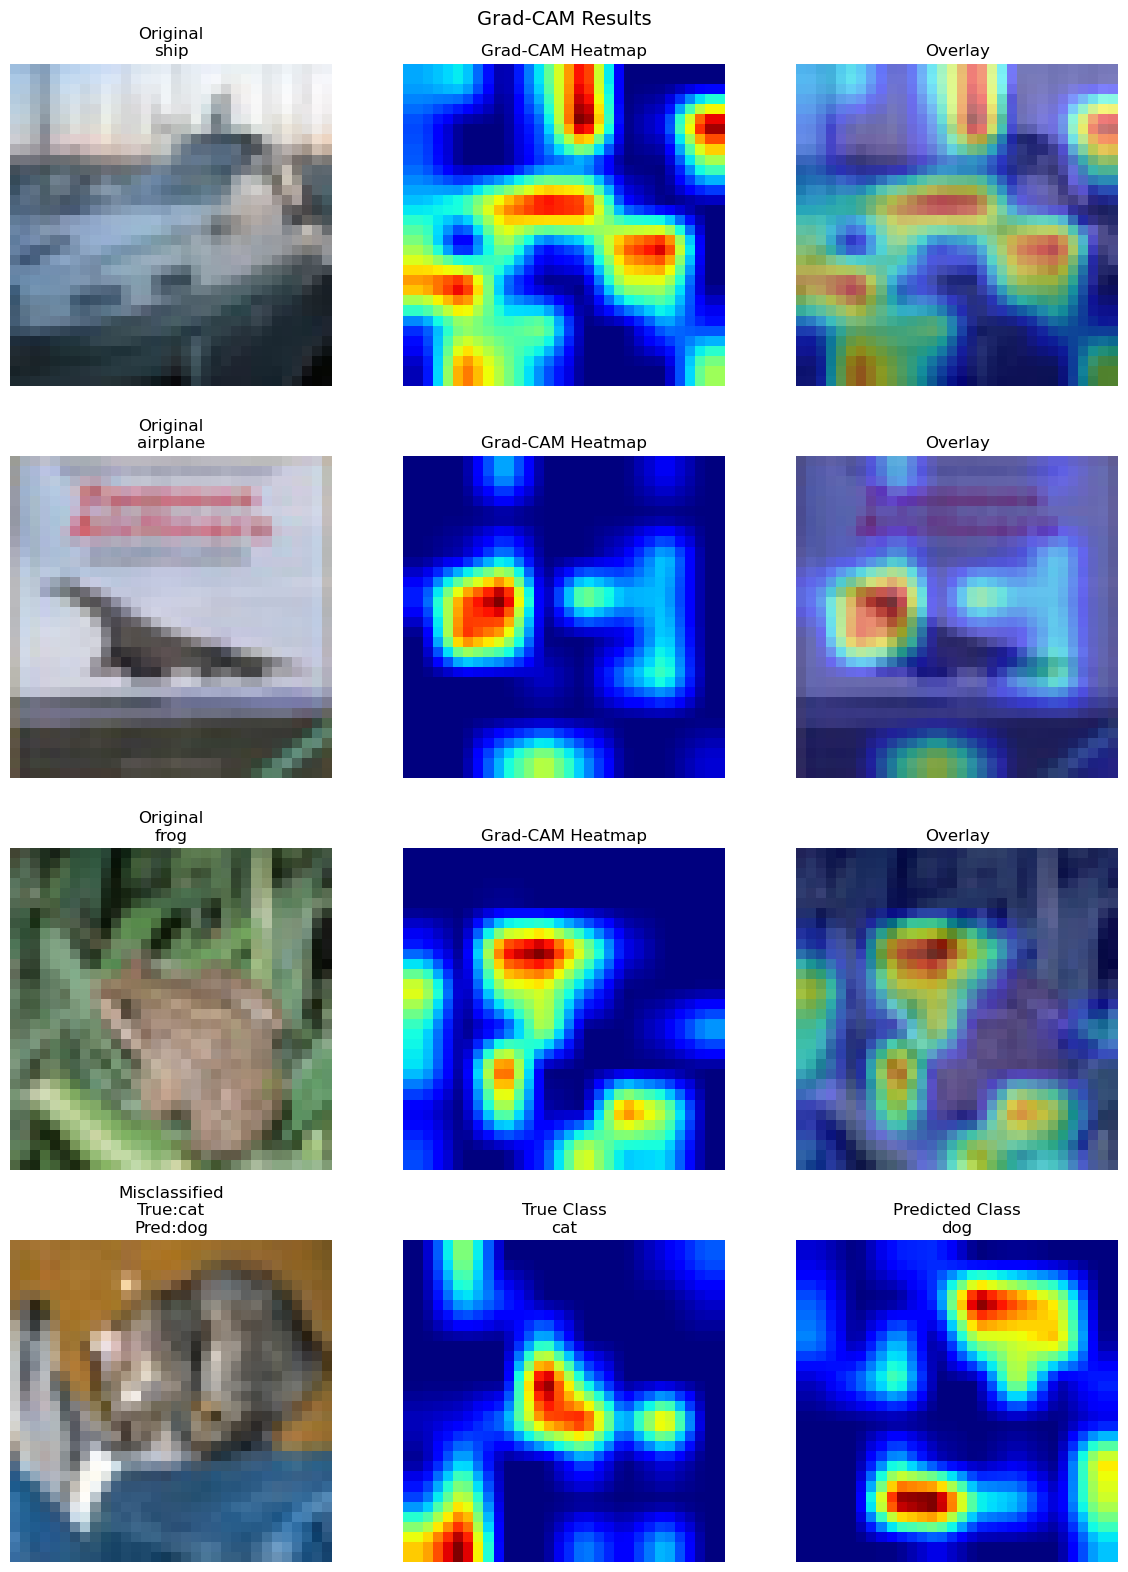


Misclassified image:
True class:      cat
Predicted class: dog
Saved as gradcam_results.png ✓


In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

def compute_gradcam(model, image, class_idx, last_conv_name='conv3'):
    # Build functional model properly
    inp = tf.keras.Input(shape=(32, 32, 3))
    x = inp
    conv_out = None
    final_out = None
    
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_name:
            conv_out = x
    final_out = x
    
    grad_model = tf.keras.Model(inputs=inp, outputs=[conv_out, final_out])
    
    with tf.GradientTape() as tape:
        inputs = tf.cast(image, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)

    heatmap = heatmap.numpy()
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap_resized = tf.image.resize(
        heatmap[..., tf.newaxis], [32, 32]
    ).numpy().squeeze()

    return heatmap_resized

cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Get predictions on test set
predictions = cifar_model.predict(cifar_test_x_p[:200], verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(cifar_test_y_p[:200], axis=1)

# Find 3 correctly classified and 1 misclassified
correct_idxs = np.where(pred_classes == true_classes)[0][:3]
wrong_idxs   = np.where(pred_classes != true_classes)[0][:1]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# Plot 3 correct
for i, idx in enumerate(correct_idxs):
    image    = cifar_test_x_p[idx:idx+1]
    true_cls = true_classes[idx]
    heatmap  = compute_gradcam(cifar_model, image, true_cls)

    axes[i, 0].imshow(cifar_test_x_p[idx])
    axes[i, 0].set_title(f'Original\n{cifar_classes[true_cls]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title('Grad-CAM Heatmap')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(cifar_test_x_p[idx])
    axes[i, 2].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')

# Plot misclassified
idx       = wrong_idxs[0]
image     = cifar_test_x_p[idx:idx+1]
true_cls  = true_classes[idx]
pred_cls  = pred_classes[idx]

heatmap_true = compute_gradcam(cifar_model, image, true_cls)
heatmap_pred = compute_gradcam(cifar_model, image, pred_cls)

axes[3, 0].imshow(cifar_test_x_p[idx])
axes[3, 0].set_title(f'Misclassified\nTrue:{cifar_classes[true_cls]}\nPred:{cifar_classes[pred_cls]}')
axes[3, 0].axis('off')

axes[3, 1].imshow(heatmap_true, cmap='jet')
axes[3, 1].set_title(f'True Class\n{cifar_classes[true_cls]}')
axes[3, 1].axis('off')

axes[3, 2].imshow(heatmap_pred, cmap='jet')
axes[3, 2].set_title(f'Predicted Class\n{cifar_classes[pred_cls]}')
axes[3, 2].axis('off')

plt.suptitle('Grad-CAM Results', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMisclassified image:")
print(f"True class:      {cifar_classes[true_cls]}")
print(f"Predicted class: {cifar_classes[pred_cls]}")
print("Saved as gradcam_results.png ✓")

## Task 4 - Problem 3 Observations

**Misclassified Image:**
- True class: cat
- Predicted class: dog

**Interpretation of Grad-CAM heatmap:**
The Grad-CAM heatmap for the correctly classified images highlights 
the most important regions of the object itself, showing the model 
is focusing on the right features.

For the misclassified cat image predicted as dog, the heatmap for 
the true class (cat) and predicted class (dog) highlight similar 
regions because cats and dogs share very similar visual features 
like fur texture, ears, and face shape. This shows the model has 
not learned to distinguish the subtle differences between cats and 
dogs and is instead focusing on shared features.

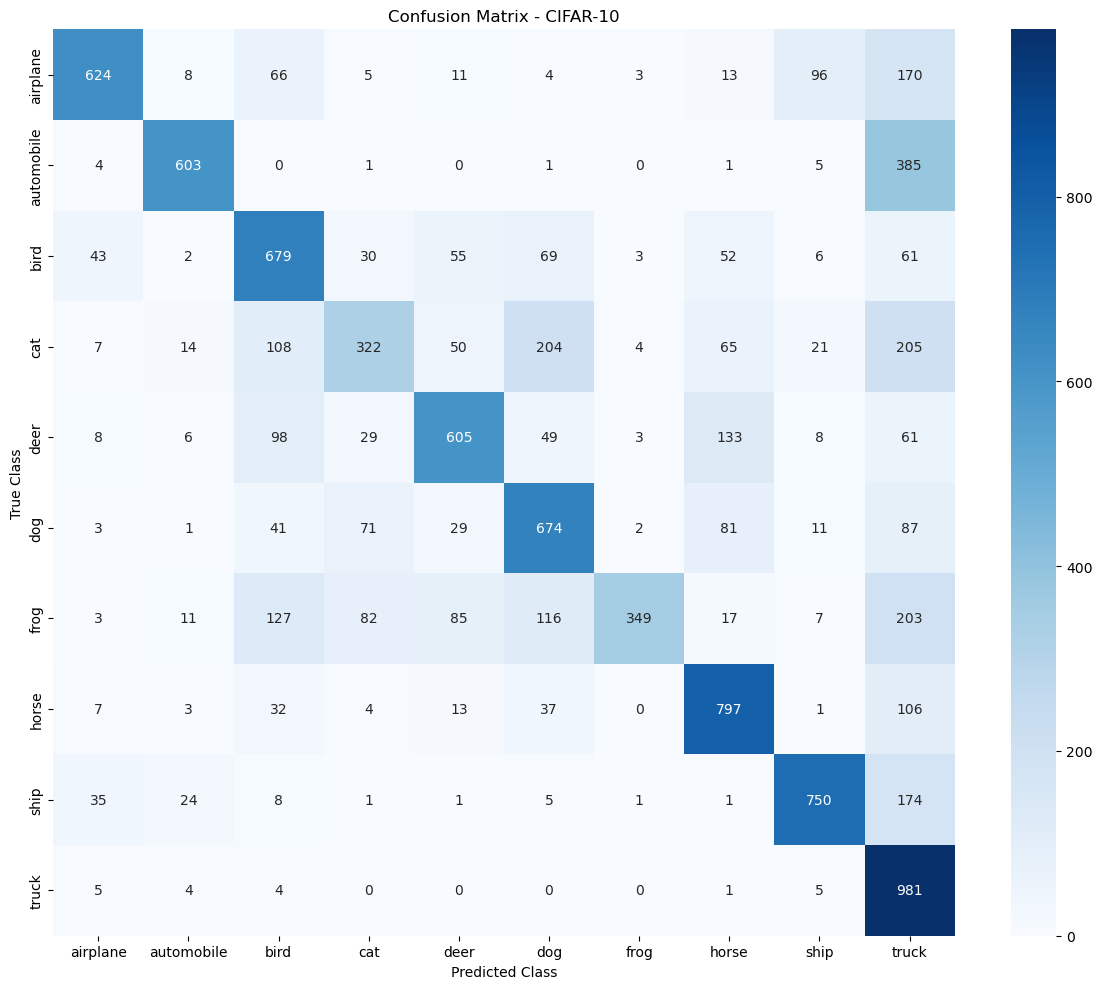

Saved as confusion_matrix.png ✓

=== Classification Report ===
              precision    recall  f1-score   support

    airplane       0.84      0.62      0.72      1000
  automobile       0.89      0.60      0.72      1000
        bird       0.58      0.68      0.63      1000
         cat       0.59      0.32      0.42      1000
        deer       0.71      0.60      0.65      1000
         dog       0.58      0.67      0.62      1000
        frog       0.96      0.35      0.51      1000
       horse       0.69      0.80      0.74      1000
        ship       0.82      0.75      0.79      1000
       truck       0.40      0.98      0.57      1000

    accuracy                           0.64     10000
   macro avg       0.71      0.64      0.64     10000
weighted avg       0.71      0.64      0.64     10000


Best F1 class:  ship  → 0.7853
Worst F1 class: cat → 0.4168

Most confused pair: automobile → truck


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Get predictions on full test set
predictions = cifar_model.predict(cifar_test_x_p, verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(cifar_test_y_p, axis=1)

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=cifar_classes,
            yticklabels=cifar_classes,
            cmap='Blues')
plt.title('Confusion Matrix - CIFAR-10')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as confusion_matrix.png ✓")

# Classification report
print("\n=== Classification Report ===")
print(classification_report(true_classes, pred_classes,
                            target_names=cifar_classes))

# Find best and worst classes
report = classification_report(true_classes, pred_classes,
                               target_names=cifar_classes,
                               output_dict=True)
f1_scores = {cls: report[cls]['f1-score'] for cls in cifar_classes}
best_class  = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print(f"\nBest F1 class:  {best_class}  → {f1_scores[best_class]:.4f}")
print(f"Worst F1 class: {worst_class} → {f1_scores[worst_class]:.4f}")

# Most confused pairs
np.fill_diagonal(cm, 0)
max_idx = np.unravel_index(cm.argmax(), cm.shape)
print(f"\nMost confused pair: {cifar_classes[max_idx[0]]} → {cifar_classes[max_idx[1]]}")


## Task 4 - Problem 4 Observations

**Best and Worst Classes:**
- Highest F1-score: Ship → F1 = 0.79
- Lowest F1-score: Cat → F1 = 0.42

**Most Confused Pair:**
- Automobile → Truck (most confused)
- Cat ↔ Dog (second most confused)

**Interpretation of Confusion Matrix:**
The confusion matrix reveals that ship is the best performing class with an F1-score of 0.79, likely because ships have a visually distinctive shape and appear against a unique water background, making them easy to separate from other classes.

Cat is the worst performing class with an F1-score of only 0.42 and a very low recall of 0.32, meaning the model misses 68% of actual cats. Most cats are being misclassified as dogs due to shared visual features like fur texture, ear shape, and face structure at 32×32 resolution.

The most confused pair is automobile and truck. At low resolution, both classes share boxy rectangular shapes, wheels, and similar colour distributions, making it difficult for the model to distinguish between them. This is confirmed by truck's inflated recall of 0.98, meaning the model aggressively predicts truck for many non-truck samples including automobiles.

A notable anomaly is frog, which has very high precision of 0.96 but low recall of 0.35, meaning the model rarely predicts frog but when it does it is almost always correct. Most frogs are being absorbed into other predicted classes, particularly truck.

## Task 4 - Analysis & Reflection Questions

**Q1. Grad-CAM heatmap for correctly classified 'cat' highlights 
face region, misclassified 'cat' (predicted as 'dog') highlights 
background:**

The Grad-CAM heatmap revealing background focus for the 
misclassified cat image tells us that the model has learned 
spurious correlations between background context and class labels 
rather than learning the actual object features. This is a classic 
case of the model relying on context rather than content. To 
address this failure mode, random cropping and cutout augmentation 
can be applied during training so the model is forced to focus on 
the object itself rather than the surrounding background. Another 
strategy is to use mixup augmentation which blends two images 
together forcing the model to learn more robust and generalised 
features rather than background shortcuts.

**Q2. Why CNNs struggle to distinguish visually similar CIFAR-10 
class pairs like cat/dog and automobile/truck:**

CNNs trained on raw pixel features struggle with visually similar 
class pairs because at 32×32 resolution the fine-grained details 
that distinguish these pairs such as snout shape for cat vs dog or 
cab size for automobile vs truck are lost. Both cat and dog share 
fur texture, ear shape, and similar face structure, while 
automobile and truck share wheels, windows, and boxy shapes. An 
architectural change that could help is using attention mechanisms 
such as a Squeeze-and-Excitation block which allows the model to 
focus on the most discriminative channel features. An additional 
input modality such as depth information or higher resolution 
images could also help the model distinguish these fine-grained 
differences.

**Q3. Dead filters in filter visualisation:**

Dead filters are filters whose weight values are all near zero and 
contribute nothing to the network's predictions. They are most 
commonly caused by the ReLU activation function through a 
phenomenon known as the dying ReLU problem, where neurons receive 
consistently negative inputs and their gradients become zero, 
causing them to stop updating entirely. One remedy is to replace 
ReLU with Leaky ReLU which allows a small non-zero gradient for 
negative inputs, preventing neurons from dying permanently during 
training.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# Set random seed
tf.random.set_seed(42)
np.random.seed(42)

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Resize images from 32x32 to 96x96
x_train_resized = tf.image.resize(x_train, (96, 96)).numpy()
x_test_resized = tf.image.resize(x_test, (96, 96)).numpy()

# Apply VGG16 preprocessing
x_train_preprocessed = preprocess_input(x_train_resized)
x_test_preprocessed = preprocess_input(x_test_resized)

# One-hot encode labels
y_train_ohe = tf.keras.utils.to_categorical(y_train, 10)
y_test_ohe = tf.keras.utils.to_categorical(y_test, 10)

# Load VGG16 base without top, freeze all layers
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)
base_model.trainable = False

# Build classification head
inputs = tf.keras.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Print trainable vs frozen parameters
total_params = model.count_params()
trainable_params = sum([
    tf.size(w).numpy() for w in model.trainable_weights
])
frozen_params = sum([
    tf.size(w).numpy() for w in model.non_trainable_weights
])

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")

model.summary()

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train only the head for 10 epochs
history = model.fit(
    x_train_preprocessed, y_train_ohe,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Feature Extraction - Frozen Base Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('tl_frozen.png')
plt.show()

print(f"\nEpoch-10 Validation Accuracy: \
{history.history['val_accuracy'][-1]:.4f}")